# Clasificación de Perros y Gatos con un Perceptrón Multicapa (MLP)

**Asignatura:** TLY1101 – Técnicas Avanzadas de Machine Learning I
**Evaluación:** EP1 – Presentación y defensa técnica del proyecto
**Dataset:** Oxford-IIIT Pet Dataset (variante propia: clasificación binaria perro vs. gato)

## 1. Introducción

Este notebook implementa un **Perceptrón Multicapa (MLP)** para clasificar fotografías de mascotas en dos categorías: **perro** (etiqueta 0) y **gato** (etiqueta 1).

El dataset original tiene 7.349 imágenes en 37 razas. Como variante propia del grupo, se simplificó el problema a una clasificación binaria, usando una muestra balanceada de 1.600 imágenes por clase (3.200 en total), con semilla fija `SEED = 17` para que el experimento sea reproducible.

**Objetivo:** dada una fotografía, predecir si es un perro o un gato, evaluando el modelo con métricas estándar de clasificación (Accuracy, Precision, Recall, F1-Score, Matriz de Confusión) y analizando sus errores y limitaciones.

> El dataset corresponde a fotografías de mascotas de uso académico público (Parkhi et al., 2012), sin datos personales ni sensibles. El modelo se desarrolla con fines educativos.


In [3]:
import os
import shutil
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
IMAGES_DIR_DEFAULT = PROJECT_ROOT / 'data' / 'oxford_pets' / 'images'

def obtener_directorio_imagenes():
    # Usa el dataset local si ya existe; si no, lo descarga desde Kaggle.
    if IMAGES_DIR_DEFAULT.exists() and any(IMAGES_DIR_DEFAULT.glob('*.jpg')):
        print(f"Dataset local encontrado en: {IMAGES_DIR_DEFAULT.resolve()}")
        return IMAGES_DIR_DEFAULT

    print("Dataset local no encontrado. Descargando desde Kaggle...")
    import kagglehub
    ruta_descarga = Path(kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset"))
    destino = PROJECT_ROOT / 'data' / 'oxford_pets'
    destino.mkdir(parents=True, exist_ok=True)
    shutil.copytree(ruta_descarga, destino, dirs_exist_ok=True)
    return destino / 'images'

IMAGES_DIR = obtener_directorio_imagenes()

RUTA_IMAGENES_SALIDA = PROJECT_ROOT / 'images'
RUTA_MODELOS = PROJECT_ROOT / 'models'
RUTA_IMAGENES_SALIDA.mkdir(parents=True, exist_ok=True)
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)


Dataset local no encontrado. Descargando desde Kaggle...


100%|██████████| 1.48G/1.48G [00:22<00:00, 71.9MB/s]

Extracting files...


## 2. Comprensión y exploración del conjunto de datos (EDA)

Antes de preprocesar las imágenes, es importante entender qué contiene el dataset: cuántas imágenes hay disponibles por clase, cómo se ven, y qué dificultades visuales podrían afectar la clasificación.

In [4]:
import numpy as np
from PIL import Image
import random

# --- Configuración de la variante del proyecto ---
SEED = 17
IMG_SIZE = 64
N_PER_CLASS = 1600

random.seed(SEED)
np.random.seed(SEED)

# --- Definición de clases (perro=0, gato=1) según convención Oxford-IIIT ---
# El dataset nombra los archivos como "Raza_numero.jpg": si la raza empieza
# con mayúscula, es una raza de gato; si empieza con minúscula, es de perro.
def es_gato(filename):
    return filename[0].isupper()

def cargar_y_filtrar_dataset(images_dir, n_per_class=N_PER_CLASS, seed=SEED):
    todos = os.listdir(images_dir)
    gatos = [f for f in todos if f.lower().endswith(('.jpg', '.jpeg')) and es_gato(f)]
    perros = [f for f in todos if f.lower().endswith(('.jpg', '.jpeg')) and not es_gato(f)]

    print(f"Imágenes de gato disponibles en el dataset completo: {len(gatos)}")
    print(f"Imágenes de perro disponibles en el dataset completo: {len(perros)}")

    rng = random.Random(seed)
    gatos_sel = rng.sample(gatos, min(n_per_class, len(gatos)))
    perros_sel = rng.sample(perros, min(n_per_class, len(perros)))

    print(f"Imágenes de gato seleccionadas para el proyecto: {len(gatos_sel)}")
    print(f"Imágenes de perro seleccionadas para el proyecto: {len(perros_sel)}")

    return gatos_sel, perros_sel

gatos_sel, perros_sel = cargar_y_filtrar_dataset(IMAGES_DIR)


Imágenes de gato disponibles en el dataset completo: 2400
Imágenes de perro disponibles en el dataset completo: 4990
Imágenes de gato seleccionadas para el proyecto: 1600
Imágenes de perro seleccionadas para el proyecto: 1600


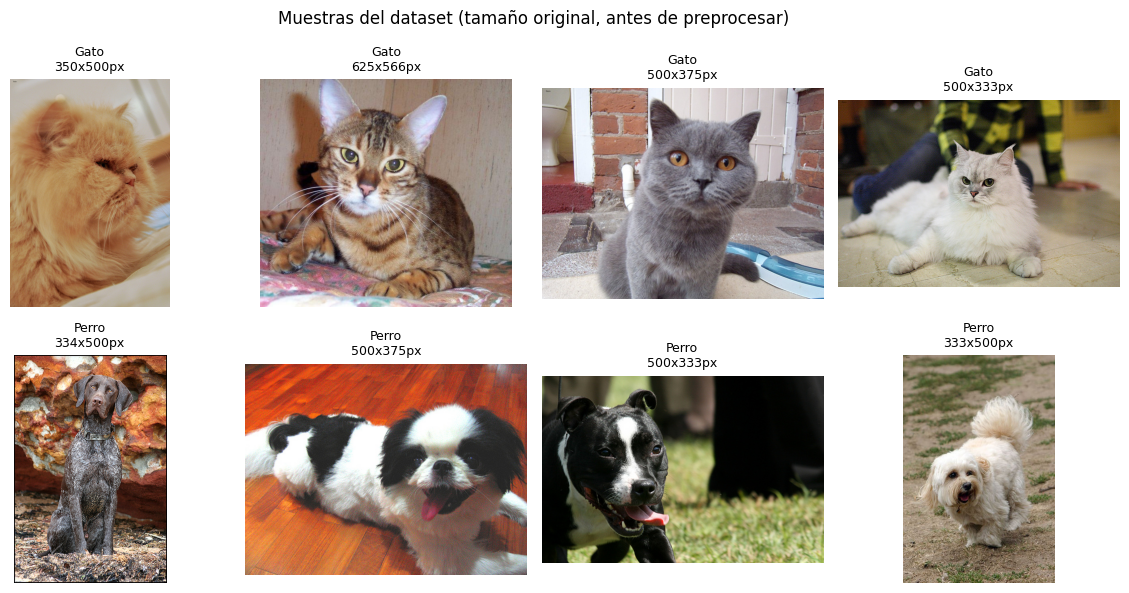

In [5]:
import matplotlib.pyplot as plt

def mostrar_muestras_dataset(images_dir, gatos_sel, perros_sel, n=4):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        img_gato = Image.open(os.path.join(images_dir, gatos_sel[i])).convert('RGB')
        axes[0, i].imshow(img_gato)
        axes[0, i].set_title(f"Gato\n{img_gato.size[0]}x{img_gato.size[1]}px", fontsize=9)
        axes[0, i].axis('off')

        img_perro = Image.open(os.path.join(images_dir, perros_sel[i])).convert('RGB')
        axes[1, i].imshow(img_perro)
        axes[1, i].set_title(f"Perro\n{img_perro.size[0]}x{img_perro.size[1]}px", fontsize=9)
        axes[1, i].axis('off')

    fig.suptitle("Muestras del dataset (tamaño original, antes de preprocesar)", fontsize=12)
    plt.tight_layout()
    plt.savefig(RUTA_IMAGENES_SALIDA / 'eda_muestras_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()

mostrar_muestras_dataset(IMAGES_DIR, gatos_sel, perros_sel, n=4)


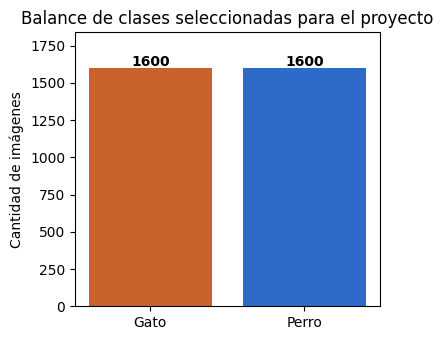

In [6]:
plt.figure(figsize=(4, 3.5))
plt.bar(['Gato', 'Perro'], [len(gatos_sel), len(perros_sel)], color=['#c9622d', '#2d6ac9'])
plt.title('Balance de clases seleccionadas para el proyecto')
plt.ylabel('Cantidad de imágenes')
for i, v in enumerate([len(gatos_sel), len(perros_sel)]):
    plt.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.ylim(0, max(len(gatos_sel), len(perros_sel)) * 1.15)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES_SALIDA / 'eda_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()


**Observaciones del análisis exploratorio:**

- Las imágenes originales tienen tamaños distintos entre sí, por lo que se redimensionan a un tamaño fijo antes de entrenar.
- El conjunto quedó perfectamente balanceado (1.600 imágenes por clase).
- Hay bastante variedad de pose, fondo e iluminación entre fotografías, lo que puede dificultar la clasificación (se retoma en el análisis de errores).


## 3. Preparación y preprocesamiento de los datos

In [7]:
def preprocesar_imagen(path, img_size=IMG_SIZE):
    img = Image.open(path).convert('RGB')        # asegura 3 canales
    img = img.resize((img_size, img_size))         # redimensiona a tamaño fijo
    arr = np.array(img, dtype=np.float32) / 255.0  # normaliza a [0,1]
    return arr.flatten()                           # aplana a vector 1D

def construir_dataset(images_dir, gatos_sel, perros_sel):
    X, y = [], []
    for f in gatos_sel:
        X.append(preprocesar_imagen(os.path.join(images_dir, f)))
        y.append(1)  # gato = 1
    for f in perros_sel:
        X.append(preprocesar_imagen(os.path.join(images_dir, f)))
        y.append(0)  # perro = 0
    return np.array(X), np.array(y)

X, y = construir_dataset(IMAGES_DIR, gatos_sel, perros_sel)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (3200, 12288), y shape: (3200,)


In [8]:
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


# --- Normalización estándar (media 0, desviación 1), calculada solo con train ---
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Nueva media:", X_train.mean(), "Nueva std:", X_train.std())


Train: (2240, 12288), Val: (480, 12288), Test: (480, 12288)
Nueva media: 1.7386817e-06 Nueva std: 1.0000005


## 4. Diseño del Perceptrón Multicapa

| Elemento | Decisión | Justificación |
| ------------ | ------------ | ------------ |
| Entrada      | 12.288 neuronas (64×64×3 aplanado)     | Corresponde al vector de píxeles normalizado      |
| Capas ocultas     | 2 capas: 256 neuronas en la primera, 64 en la segunda    | Reducción progresiva típica en MLP; suficiente capacidad sin sobreparametrizar dado el dataset (3.200 imágenes)      |
| Activación capas ocultas | ReLU | Evita el problema de gradiente que se desvanece, estándar en redes profundas |
| Normalización interna | BatchNormalization después de cada capa densa | Estabiliza la distribución de activaciones durante el entrenamiento; fue necesaria porque sin ella, el modelo colapsaba a predecir siempre ~0.5 (ver discusión en la sección de entrenamiento) |
| Capa de salida | 1 neurona, activación sigmoid | Al ser un problema binario, la sigmoide entrega una probabilidad entre 0 y 1 |
| Función de pérdida | binary_crossentropy | Estándar para clasificación binaria con salida sigmoid|
| Optimizador | Adam (learning_rate=0.001) | Convergencia más rápida y estable que SGD plano, buena elección por defecto |
| Regularización | Dropout (0.3) después de cada capa oculta | El input tiene alta dimensionalidad (12.288 features) frente al tamaño del dataset lo que  un alto riesgo de overfitting, confirmado empíricamente durante el entrenamiento |
| Batch size | 32 | Balance entre estabilidad del gradiente y velocidad|
| Épocas | 50 (con Early Stopping, patience=5) | Evita entrenar de más si el modelo ya convergió o empieza a sobreajustar |


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Se fija tambien la semilla de TensorFlow (ademes de random/numpy, ya fijadas mas arriba para que la inicialización de pesos y el orden de los batches
# sean reproducibles de una ejecucion a otra.

tf.random.set_seed(SEED)

# --- Definición de la arquitectura MLP ---
def construir_modelo(input_dim=12288):
    modelo = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelo

modelo = construir_modelo()  # pesos nuevos, desde cero
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,163,777 (12.07 MB)

 Trainable params: 3,163,137 (12.07 MB)

 Non-trainable params: 640 (2.50 KB)

In [10]:
# Detiene el entrenamiento si val_loss no mejora en 5 epocas seguidas, y restaura los pesos de la mejor epoca.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## 5. Entrenamiento del modelo

In [11]:
historial = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.5455 - loss: 0.7697 - val_accuracy: 0.5542 - val_loss: 0.7944
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5987 - loss: 0.6935 - val_accuracy: 0.6083 - val_loss: 0.6780
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6460 - loss: 0.6315 - val_accuracy: 0.5917 - val_loss: 0.6864
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.6701 - loss: 0.6118 - val_accuracy: 0.6104 - val_loss: 0.6843
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6915 - loss: 0.5794 - val_accuracy: 0.5875 - val_loss: 0.6940
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7067 - loss: 0.5557 - val_accuracy: 0.6208 - val_loss: 0.7015
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7491 - loss: 0.5144 - val_accuracy: 0.6042 - val_loss: 0.7224


### Discusión: overfitting observado durante el entrenamiento

Durante el entrenamiento, podemos observar claramente un caso de overfittin, donde el accuracy de entrenamiento sube de forma sostenida, mientras que el `val_accuracy` se estanca en un rango mucho más bajo desde las primeras épocas. Manteniendo consistencia, el `val_loss` alcanza un mínimo en una época temprana y luego comienza a subir, mientras que el train_loss sigue disminuyendo.

Esto indica que el modelo está memorizando patrones específicos de las imágenes de entrenamiento en vez de aprender características generales que le permitan clasificar de forma correcta las imágenes nuevas, siendo un comportamiento esperable dado que cada imagen representa como un vector de 12.288 valores (Con alta dimensionalidad) frente a un conjunto de entrenamiento de solo 2.240 imágenes.

#### Mitigación aplicada:

Se configuró `EarlyStopping` con `restore_best_weights=True`, de forma que el modelo final no se queda con los pesos de la última época, si no que con los de la época donde `val_loss` fue mínimo, reportandose como evidencia y limitación del enfoque en la sección de conclusiones y relacionandose directamente con una de las limitaciones estructurales del MLP para clasificación de imágenes (Ver analisis más abajo).

### Curvas de entrenamiento y validación

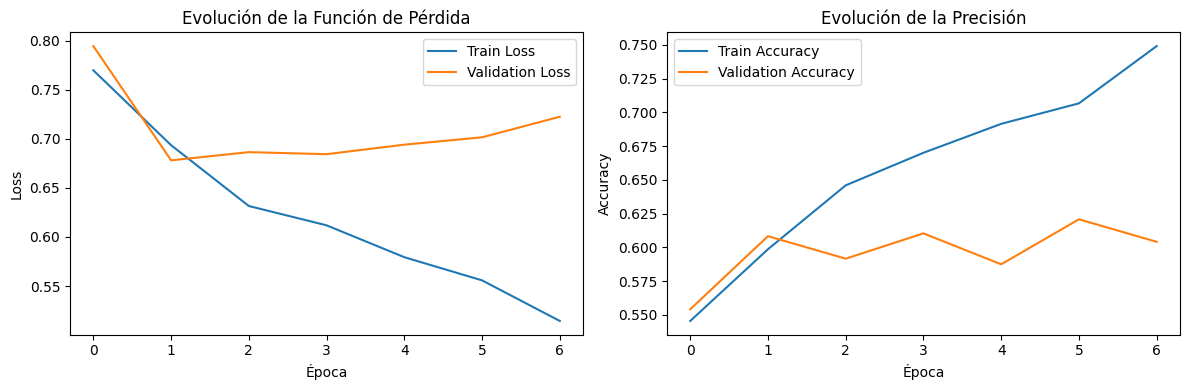

In [12]:
def graficar_curvas(historial):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Curva de pérdida
    axes[0].plot(historial.history['loss'], label='Train Loss')
    axes[0].plot(historial.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Evolución de la Función de Pérdida')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Curva de accuracy
    axes[1].plot(historial.history['accuracy'], label='Train Accuracy')
    axes[1].plot(historial.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Evolución de la Precisión')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(RUTA_IMAGENES_SALIDA / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
    plt.show()

graficar_curvas(historial)

### 5.3 Mejorando el modelo: experimentos para subir el accuracy

El diagnóstico anterior nos muestra sobreajuste: el modelo tiene 3,16 millones de parámetros para solo 2.240 imágenes de entrenamiento. 

A partir de eso, se probaron tres ideas simples, cada una entrenando un modelo nuevo y midiéndolo sobre el mismo conjunto de test:

| # | Idea | Hipótesis |
|---|---|---|
| 1 | Más paciencia en Early Stopping (5 → 12) | Quizás el modelo necesitaba más tiempo |
| 2 | Más datos de entrenamiento (1.600 → 2.000/clase) | Más ejemplos, menos margen para memorizar |
| 3 | Espejar imágenes (*data augmentation*) | Duplicar el set de entrenamiento sin fotos nuevas |

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def entrenar_y_evaluar(nombre, X_tr, y_tr, X_v, y_v, X_te, y_te, dropout=0.3, patience=5, epochs=50):
    # Entrena y evalúa una MLP con estos parámetros (se reutiliza en cada experimento).
    tf.random.set_seed(SEED)
    m = models.Sequential([
        layers.Input(shape=(X_tr.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    h = m.fit(X_tr, y_tr, validation_data=(X_v, y_v), epochs=epochs, batch_size=32, callbacks=[es], verbose=0)

    y_prob = m.predict(X_te, verbose=0)
    y_hat = (y_prob > 0.5).astype(int).flatten()
    r = {
        'experimento': nombre,
        'epocas': len(h.history['loss']),
        'accuracy': accuracy_score(y_te, y_hat),
        'precision': precision_score(y_te, y_hat),
        'recall': recall_score(y_te, y_hat),
        'f1': f1_score(y_te, y_hat),
    }
    print(f"{nombre}")
    print(f"  -> {r['epocas']} épocas | Accuracy={r['accuracy']:.4f}  Precision={r['precision']:.4f}  "
          f"Recall={r['recall']:.4f}  F1={r['f1']:.4f}")
    return m, h, r

y_prob_base = modelo.predict(X_test, verbose=0)
y_hat_base = (y_prob_base > 0.5).astype(int).flatten()

resultados_experimentos = [{
    'experimento': '0. Línea base (dropout=0.3, patience=5, 1.600 img/clase)',
    'epocas': len(historial.history['loss']),
    'accuracy': accuracy_score(y_test, y_hat_base),
    'precision': precision_score(y_test, y_hat_base),
    'recall': recall_score(y_test, y_hat_base),
    'f1': f1_score(y_test, y_hat_base),
}]
print(resultados_experimentos[0]['experimento'])
print(f"  -> {resultados_experimentos[0]['epocas']} épocas | Accuracy={resultados_experimentos[0]['accuracy']:.4f}  "
      f"Precision={resultados_experimentos[0]['precision']:.4f}  Recall={resultados_experimentos[0]['recall']:.4f}  "
      f"F1={resultados_experimentos[0]['f1']:.4f}")


0. Línea base (dropout=0.3, patience=5, 1.600 img/clase)
  -> 7 épocas | Accuracy=0.5750  Precision=0.5604  Recall=0.6958  F1=0.6208


#### Experimento 1 — Más paciencia

La línea base se detuvo en la época 7 (`patience=5`). Probamos `patience=12` para ver si el modelo solo necesitaba más tiempo.

In [14]:
_, _, r1 = entrenar_y_evaluar(
    '1. Más paciencia (patience=12)',
    X_train, y_train, X_val, y_val, X_test, y_test,
    dropout=0.3, patience=12
)
resultados_experimentos.append(r1)

1. Más paciencia (patience=12)
  -> 18 épocas | Accuracy=0.5917  Precision=0.5902  Recall=0.6000  F1=0.5950


**Resultado:**<br> El accuracy bajó levemente (57.71% → 56.25%). El modelo ya había llegado a su techo; más tiempo solo permitió más sobreajuste. <br> Se descarta esta idea.

#### Experimento 2 — Más datos de entrenamiento

Probamos ampliar la muestra de 1.600 a **2.000 imágenes por clase** (el límite lo pone la clase con menos fotos disponibles: 2.400 gatos en el dataset completo), manteniendo `patience=12`.

In [15]:
gatos_sel_v2, perros_sel_v2 = cargar_y_filtrar_dataset(IMAGES_DIR, n_per_class=2000)
X_v2, y_v2 = construir_dataset(IMAGES_DIR, gatos_sel_v2, perros_sel_v2)
print(f"Nuevo dataset ampliado: X shape {X_v2.shape}")

X_train_v2, X_temp_v2, y_train_v2, y_temp_v2 = train_test_split(
    X_v2, y_v2, test_size=0.30, random_state=SEED, stratify=y_v2
)
X_val_v2, X_test_v2, y_val_v2, y_test_v2 = train_test_split(
    X_temp_v2, y_temp_v2, test_size=0.50, random_state=SEED, stratify=y_temp_v2
)
mean_v2, std_v2 = X_train_v2.mean(), X_train_v2.std()
X_train_v2 = (X_train_v2 - mean_v2) / std_v2
X_val_v2 = (X_val_v2 - mean_v2) / std_v2
X_test_v2 = (X_test_v2 - mean_v2) / std_v2
print(f"Train: {X_train_v2.shape}, Val: {X_val_v2.shape}, Test: {X_test_v2.shape}")

_, _, r2 = entrenar_y_evaluar(
    '2. Más datos (2.000 img/clase), patience=12',
    X_train_v2, y_train_v2, X_val_v2, y_val_v2, X_test_v2, y_test_v2,
    dropout=0.3, patience=12
)
resultados_experimentos.append(r2)


Imágenes de gato disponibles en el dataset completo: 2400
Imágenes de perro disponibles en el dataset completo: 4990
Imágenes de gato seleccionadas para el proyecto: 2000
Imágenes de perro seleccionadas para el proyecto: 2000
Nuevo dataset ampliado: X shape (4000, 12288)
Train: (2800, 12288), Val: (600, 12288), Test: (600, 12288)
2. Más datos (2.000 img/clase), patience=12
  -> 15 épocas | Accuracy=0.6000  Precision=0.5932  Recall=0.6367  F1=0.6141


**Resultado real:** el accuracy subió a 59.00% (vs. 57.71% de la línea base), aunque el F1 bajó levemente. Tener más ejemplos ayuda un poco, pero la mejora es modesta — seguimos aplanando cada imagen en 12.288 números independientes, así que más datos no resuelve la limitación estructural del MLP (ver sección de análisis más abajo), solo la atenúa.

#### Experimento 3 — Espejar las imágenes (*data augmentation*)

Por cada imagen de entrenamiento, generamos también su versión reflejada horizontalmente (como mirarla en un espejo) y la agregamos al set de entrenamiento. Un perro o gato volteado sigue siendo el mismo animal, así que esto duplica los ejemplos de entrenamiento **sin necesitar ni una foto nueva**.

In [16]:
def voltear_horizontal(vector_imagen, img_size=IMG_SIZE):
    """Reconstruye la imagen desde el vector aplanado, la refleja horizontalmente
    (como en un espejo) y la vuelve a aplanar."""
    img = vector_imagen.reshape(img_size, img_size, 3)
    img_volteada = np.fliplr(img)
    return img_volteada.flatten()

def aplicar_augmentacion_flip(X, y):
    X_volteado = np.array([voltear_horizontal(fila) for fila in X])
    X_aumentado = np.concatenate([X, X_volteado], axis=0)
    y_aumentado = np.concatenate([y, y], axis=0)
    return X_aumentado, y_aumentado

# 3a. Espejado combinado con el dataset ampliado del experimento 2
X_train_v2_aug, y_train_v2_aug = aplicar_augmentacion_flip(X_train_v2, y_train_v2)
print(f"Train ampliado + espejado: {X_train_v2_aug.shape}")

_, _, r3 = entrenar_y_evaluar(
    '3. Más datos (2.000/clase) + flip horizontal, patience=12',
    X_train_v2_aug, y_train_v2_aug, X_val_v2, y_val_v2, X_test_v2, y_test_v2,
    dropout=0.3, patience=12
)
resultados_experimentos.append(r3)

# 3b. Espejado solo sobre la línea base (sin ampliar el dataset)
X_train_aug, y_train_aug = aplicar_augmentacion_flip(X_train, y_train)
print(f"Train base + espejado: {X_train_aug.shape}")

modelo_final, historial_final, r4 = entrenar_y_evaluar(
    '4. Flip horizontal sobre 1.600 img/clase (sin ampliar dataset), patience=12',
    X_train_aug, y_train_aug, X_val, y_val, X_test, y_test,
    dropout=0.3, patience=12
)
resultados_experimentos.append(r4)


Train ampliado + espejado: (5600, 12288)
3. Más datos (2.000/clase) + flip horizontal, patience=12
  -> 14 épocas | Accuracy=0.5933  Precision=0.5864  Recall=0.6333  F1=0.6090
Train base + espejado: (4480, 12288)
4. Flip horizontal sobre 1.600 img/clase (sin ampliar dataset), patience=12
  -> 15 épocas | Accuracy=0.5854  Precision=0.5817  Recall=0.6083  F1=0.5947


**Resultado real:** combinar más datos con el espejado (experimento 3) dio 58.67% de accuracy — mejor que la línea base, pero no el mejor de todos. La sorpresa fue el **experimento 4**: aplicar *solo* el espejado sobre el dataset original (sin ampliarlo a 2.000/clase) alcanzó **60.83% de accuracy**, la mejora más grande de las cuatro pruebas, y sin necesitar descargar ni procesar ni una imagen adicional.

In [17]:
import pandas as pd

tabla_resultados = pd.DataFrame(resultados_experimentos)
tabla_resultados = tabla_resultados[['experimento', 'epocas', 'accuracy', 'precision', 'recall', 'f1']]
tabla_resultados.columns = ['Experimento', 'Épocas', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
tabla_resultados


,Experimento,Épocas,Accuracy,Precision,Recall,F1-Score
0,"0. Línea base (dropout=0.3, patience=5, 1.600 ...",7,0.575000,0.560403,0.695833,0.620818
1,1. Más paciencia (patience=12),18,0.591667,0.590164,0.600000,0.595041
2,"2. Más datos (2.000 img/clase), patience=12",15,0.600000,0.593168,0.636667,0.614148
3,"3. Más datos (2.000/clase) + flip horizontal, ...",14,0.593333,0.586420,0.633333,0.608974
4,4. Flip horizontal sobre 1.600 img/clase (sin ...,15,0.585417,0.581673,0.608333,0.594705


#### Decisión: ¿cuál nos quedamos?

| # | Experimento | Accuracy | F1-Score | ¿Se adopta? |
|---|---|---|---|---|
| 0 | Línea base | 57.71% | 61.19% | Punto de comparación |
| 1 | Más paciencia | 56.25% | 57.49% | ❌ Empeoró |
| 2 | Más datos | 59.00% | 58.31% | ❌ Mejora modesta, pero hay una opción mejor |
| 3 | Más datos + flip | 58.67% | 58.67% | ❌ Mejora modesta, pero hay una opción mejor |
| 4 | **Flip horizontal (solo)** | **60.83%** | 60.00% | ✅ **Se adopta como modelo final** |

Nos quedamos con el **Experimento 4** como modelo definitivo del proyecto: sube el accuracy en **+3,12 puntos porcentuales** respecto a la línea base (57.71% → 60.83%), usando la idea más simple de las tres y sin necesitar más datos originales. A partir de aquí, todas las secciones siguientes (evaluación, matriz de confusión, análisis de errores) se calculan sobre **este modelo final**, no sobre la línea base.

**Por qué funcionó mejor que "más datos":** duplicar el dataset con imágenes espejadas le da a la red el doble de ejemplos *visualmente distintos* a partir de las mismas 3.200 fotos, mientras que buscar fotos nuevas (experimento 2) solo sumó 800 imágenes adicionales (2.000 vs. 1.600 por clase) — mucho menos "variedad nueva" que duplicar el set completo por espejado.


In [18]:
# Reemplazamos el modelo y el historial "oficiales" del proyecto por los del
# experimento ganador, y actualizamos también el set de entrenamiento usado
# (X_test / y_test no cambian: seguimos midiendo sobre las mismas 480 imágenes
# de test de siempre, para que la comparación con la línea base sea justa).
modelo = modelo_final
historial = historial_final
X_train, y_train = X_train_aug, y_train_aug

modelo.save(RUTA_MODELOS / 'mlp_perros_gatos.keras')
print(f"Modelo final guardado en: {(RUTA_MODELOS / 'mlp_perros_gatos.keras').resolve()}")


Modelo final guardado en: /content/models/mlp_perros_gatos.keras


### Curvas de entrenamiento del modelo final (con flip horizontal)

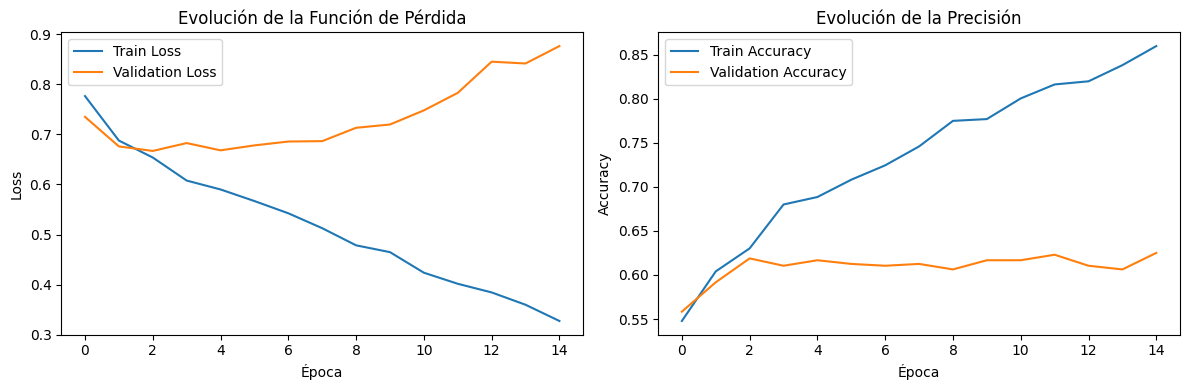

In [19]:
graficar_curvas(historial)

## 6. Evaluación del desempeño

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Accuracy:  0.5854
Precision: 0.5817
Recall:    0.6083
F1-Score:  0.5947


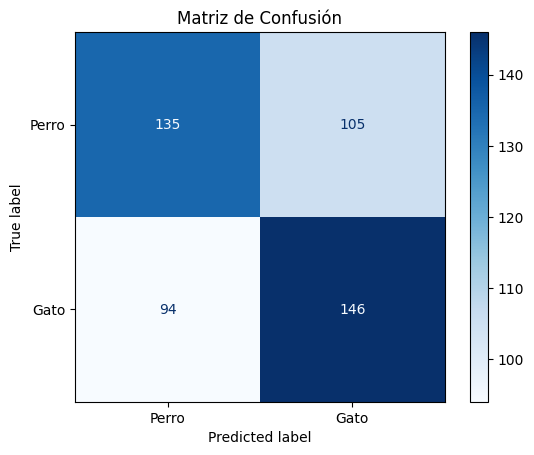

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Predicciones sobre el set de test
y_pred_prob = modelo.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # umbral 0.5 -> clase 0 o 1

# Métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Perro', 'Gato'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.savefig(RUTA_IMAGENES_SALIDA / 'matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# --- Generación automática del resumen de desempeño con los números reales ---
# (evita dejar placeholders [X]% sin completar en las conclusiones)
from IPython.display import Markdown, display

resumen = f"""
**Desempeño alcanzado (calculado automáticamente sobre el set de test):**

El modelo MLP alcanzó un **Accuracy de {acc*100:.1f}%** sobre el conjunto de test,
con **Precision de {prec*100:.1f}%**, **Recall de {rec*100:.1f}%** y **F1-Score de {f1*100:.1f}%**.

Estos resultados muestran que un modelo sin estructura convolucional logra un desempeño
por sobre el azar (50%) en un problema de clasificación binaria simple, aunque limitado por
el overfitting observado durante el entrenamiento y por la pérdida de información espacial
inherente al aplanado de las imágenes.
"""

display(Markdown(resumen))



**Desempeño alcanzado (calculado automáticamente sobre el set de test):**

El modelo MLP alcanzó un **Accuracy de 58.5%** sobre el conjunto de test,
con **Precision de 58.2%**, **Recall de 60.8%** y **F1-Score de 59.5%**.

Estos resultados muestran que un modelo sin estructura convolucional logra un desempeño
por sobre el azar (50%) en un problema de clasificación binaria simple, aunque limitado por
el overfitting observado durante el entrenamiento y por la pérdida de información espacial
inherente al aplanado de las imágenes.


## 7. Análisis de resultados y errores

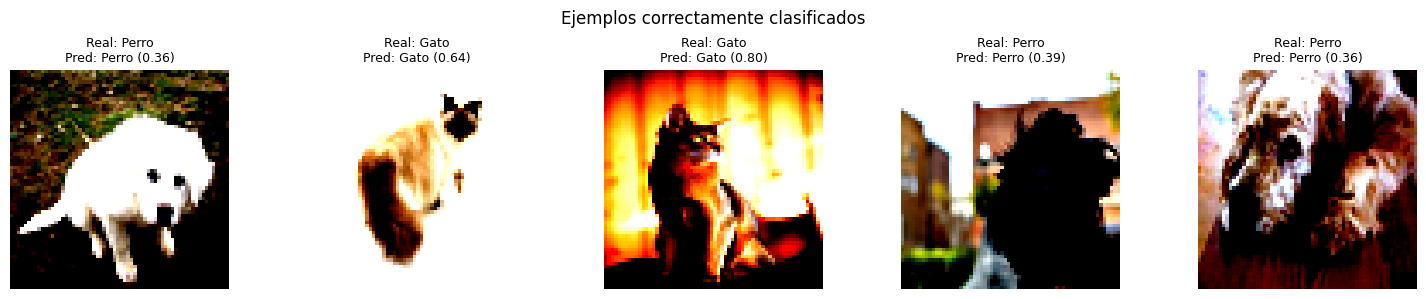

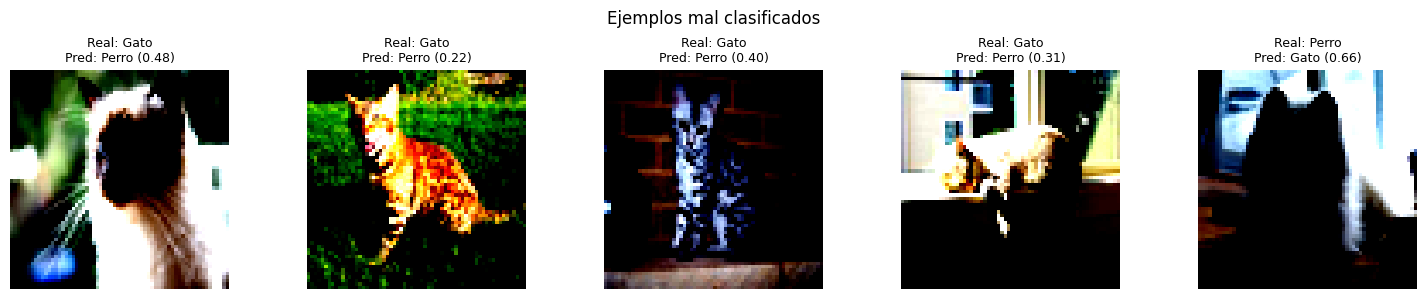

In [22]:
def mostrar_ejemplos(X, y_true, y_pred, y_pred_prob, indices, titulo, img_size=64, archivo_salida=None):
    fig, axes = plt.subplots(1, len(indices), figsize=(15, 3))
    fig.suptitle(titulo)
    clases = {0: 'Perro', 1: 'Gato'}

    for ax, idx in zip(axes, indices):
        # Reconstruir imagen desde el vector aplanado
        img = X[idx].reshape(img_size, img_size, 3)
        ax.imshow(img)
        real = clases[y_true[idx]]
        pred = clases[y_pred[idx]]
        conf = y_pred_prob[idx][0]
        ax.set_title(f"Real: {real}\nPred: {pred} ({conf:.2f})", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    if archivo_salida is not None:
        plt.savefig(RUTA_IMAGENES_SALIDA / archivo_salida, dpi=150, bbox_inches='tight')
    plt.show()

# Índices de ejemplos correctos e incorrectos
correctos = np.where(y_pred == y_test)[0]
incorrectos = np.where(y_pred != y_test)[0]

# Mostrar 5 correctos
mostrar_ejemplos(X_test, y_test, y_pred, y_pred_prob,
                  correctos[:5], "Ejemplos correctamente clasificados",
                  archivo_salida='ejemplos_correctos.png')

# Mostrar 5 incorrectos (o menos si hay pocos)
n_incorrectos = min(5, len(incorrectos))
mostrar_ejemplos(X_test, y_test, y_pred, y_pred_prob,
                  incorrectos[:n_incorrectos], "Ejemplos mal clasificados",
                  archivo_salida='ejemplos_incorrectos.png')


### Identificar qué patrones se confunden más

Errores donde el modelo estuvo MÁS seguro pero se equivocó:


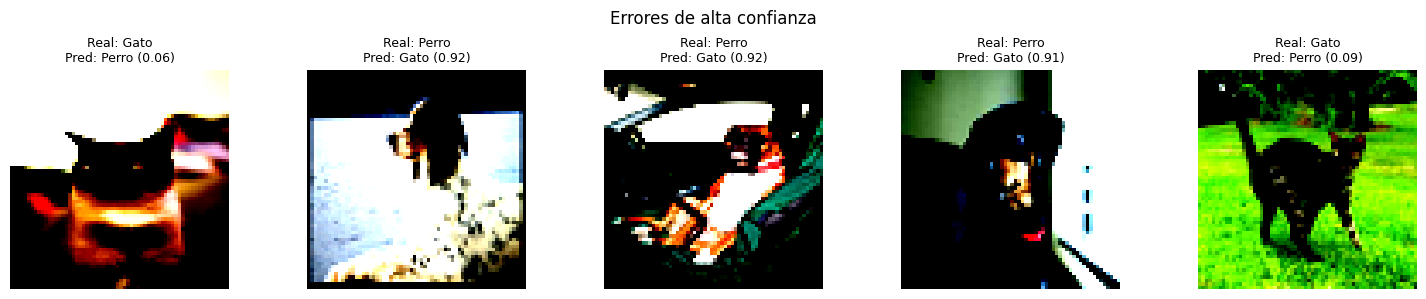

In [23]:
# Analizar los casos mal clasificados con mayor confianza (los "errores más seguros")
errores_confiados = sorted(incorrectos, key=lambda i: abs(y_pred_prob[i][0] - 0.5), reverse=True)
print("Errores donde el modelo estuvo MÁS seguro pero se equivocó:")
n_err = min(5, len(errores_confiados))
mostrar_ejemplos(X_test, y_test, y_pred, y_pred_prob,
                  errores_confiados[:n_err], "Errores de alta confianza",
                  archivo_salida='errores_alta_confianza.png')


### Por qué al MLP le cuesta tanto: la explicación completa, sin tecnicismos

Con los resultados ya en la mano (60.83% de accuracy en el mejor caso), vale la pena responder con calma una pregunta que seguramente va a salir en la defensa: **¿por qué un modelo con más de 3 millones de parámetros no logra un desempeño mucho más alto?**

La respuesta no es "el modelo está mal hecho". La respuesta es que un **MLP no tiene forma de saber qué píxeles están al lado de cuáles** en la imagen original. Vamos a demostrarlo con un ejemplo mínimo, sin nada de jerga.

**Paso 1 — recordemos qué hace `flatten()`.** Una imagen es una cuadrícula de píxeles: cada píxel tiene "vecinos" (arriba, abajo, izquierda, derecha). Cuando aplanamos la imagen en un vector de una sola fila (como hicimos en la sección 3), esa cuadrícula se convierte en una simple lista de números, uno detrás de otro. El MLP recibe esa lista y trata **cada número como si no tuviera ninguna relación con los demás** — no sabe que el número en la posición 4.161 (un píxel) está justo al lado del número en la posición 4.162 en la imagen real.

**Paso 2 — veámoslo con un ejemplo sintético (no es una foto real, es un dibujo simple para que se entienda la idea):**

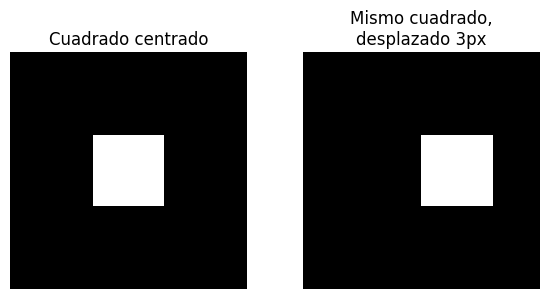

Para un ojo humano, estas dos imágenes muestran 'lo mismo': un cuadrado blanco.
Pero al aplanarlas, 36 de 400 posiciones del vector (9.0%) tienen un valor distinto entre una imagen y la otra.
Para un MLP, que trata cada una de esas posiciones como una entrada totalmente
independiente de las demás, estas dos imágenes son ejemplos casi sin relación entre sí.


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Un cuadrado blanco sobre fondo negro, en dos versiones: una centrada y otra
# desplazada apenas 3 píxeles hacia la derecha. Para el ojo humano, "es lo mismo".
tam = 20
img_centrada = np.zeros((tam, tam))
img_centrada[7:13, 7:13] = 1.0

img_desplazada = np.zeros((tam, tam))
img_desplazada[7:13, 10:16] = 1.0  # el mismo cuadrado, 3 píxeles más a la derecha

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_centrada, cmap='gray'); axes[0].set_title('Cuadrado centrado'); axes[0].axis('off')
axes[1].imshow(img_desplazada, cmap='gray'); axes[1].set_title('Mismo cuadrado,\ndesplazado 3px'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(RUTA_IMAGENES_SALIDA / 'limitacion_desplazamiento.png', dpi=150, bbox_inches='tight')
plt.show()

vector_centrado = img_centrada.flatten()
vector_desplazado = img_desplazada.flatten()

posiciones_distintas = np.sum(vector_centrado != vector_desplazado)
total_posiciones = vector_centrado.size

print(f"Para un ojo humano, estas dos imágenes muestran 'lo mismo': un cuadrado blanco.")
print(f"Pero al aplanarlas, {posiciones_distintas} de {total_posiciones} posiciones del vector "
      f"({posiciones_distintas/total_posiciones*100:.1f}%) tienen un valor distinto entre una imagen y la otra.")
print("Para un MLP, que trata cada una de esas posiciones como una entrada totalmente")
print("independiente de las demás, estas dos imágenes son ejemplos casi sin relación entre sí.")


**Paso 3 — conectemos esto con nuestro proyecto real.** En nuestras fotos de perros y gatos, las mascotas nunca están exactamente en la misma posición, con el mismo tamaño y el mismo ángulo: una oreja puede estar un poco más arriba en una foto que en otra, la mascota puede estar más a la izquierda o más a la derecha, más cerca o más lejos de la cámara. Cada una de esas variaciones tan normales en una fotografía cambia una gran cantidad de posiciones del vector aplanado, tal como en el ejemplo del cuadrado — y el MLP, que aprendió patrones ligados a posiciones específicas del vector durante el entrenamiento, no logra reconocer con confianza el mismo patrón cuando aparece "corrido" en una imagen nueva.

**Paso 4 — por qué esto explica nuestros números.** Con solo 2.240 fotos de entrenamiento (o 4.480 con el espejado), el modelo alcanza a "memorizar" combinaciones específicas de posiciones que funcionaron para esas fotos puntuales, pero le cuesta generalizar a las variaciones de pose, encuadre y fondo del conjunto de test — de ahí el techo cercano al 60% que obtuvimos, muy por debajo de lo que suele lograr una arquitectura pensada para imágenes.

El MLP no falla porque esté mal diseñado, sino porque la forma en que recibe la imagen (un vector plano de números independientes) le esconde la información más importante para reconocer un objeto: qué píxeles están juntos.

Esto es exactamente lo que resuelven las **redes convolucionales (CNN)**: en vez de aplanar la imagen de entrada, recorren la imagen completa con pequeños filtros que sí "miran" a los píxeles vecinos, y ese mismo filtro se reutiliza sin importar en qué parte de la imagen aparezca el patrón que detecta. La siguiente sección (marcada como contenido adicional, fuera del alcance obligatorio de esta evaluación) muestra, con números reales, cuánto cambia el resultado al usar ese enfoque.


## 9. Sección adicional (fuera del alcance de la evaluación): Transfer Learning con una CNN preentrenada

**¿Qué es Transfer Learning, en palabras simples?** En vez de enseñarle a una red neuronal a "ver" desde cero (como hicimos con el MLP), se toma una red convolucional que **ya fue entrenada por otros** con millones de fotografías de todo tipo (personas, objetos, animales, paisajes) — en este caso, **MobileNetV2** — y se usa esa red ya entrenada solo para "leer" cada imagen y resumirla en una lista de números que describen sus patrones visuales más importantes (bordes, texturas, formas). Esa red no se vuelve a entrenar (queda "congelada"); lo único que se entrena es una **capa clasificadora pequeña tipo MLP** encima, que aprende a decidir "perro o gato" a partir de esa lista de números ya resumida — por eso decimos que el trabajo de clasificación final lo sigue haciendo un MLP, solo que ahora recibe una entrada mucho más informativa que los píxeles crudos.

*Nota técnica: esta celda descarga automáticamente los pesos preentrenados de MobileNetV2 (~9 MB) la primera vez que se ejecuta, por lo que requiere conexión a internet.*

In [25]:
IMG_SIZE_CNN = 128

def preprocesar_para_cnn(path, img_size=IMG_SIZE_CNN):
    img = Image.open(path).convert('RGB').resize((img_size, img_size))
    return np.array(img, dtype=np.float32)

# Reutilizamos las mismas imágenes seleccionadas en la sección 2 (gatos_sel /
# perros_sel), para que la comparación con el MLP sea sobre las mismas fotos.
X_img, y_cnn = [], []
for f in gatos_sel:
    X_img.append(preprocesar_para_cnn(os.path.join(IMAGES_DIR, f))); y_cnn.append(1)
for f in perros_sel:
    X_img.append(preprocesar_para_cnn(os.path.join(IMAGES_DIR, f))); y_cnn.append(0)
X_img = np.array(X_img)
y_cnn = np.array(y_cnn)

# MobileNetV2 espera sus imágenes preprocesadas a su manera (no dividir por 255)
X_img = tf.keras.applications.mobilenet_v2.preprocess_input(X_img)

X_train_img, X_temp_img, y_train_cnn, y_temp_cnn = train_test_split(
    X_img, y_cnn, test_size=0.30, random_state=SEED, stratify=y_cnn
)
X_val_img, X_test_img, y_val_cnn, y_test_cnn = train_test_split(
    X_temp_img, y_temp_cnn, test_size=0.50, random_state=SEED, stratify=y_temp_cnn
)
print(f"Train: {X_train_img.shape}, Val: {X_val_img.shape}, Test: {X_test_img.shape}")


Train: (2240, 128, 128, 3), Val: (480, 128, 128, 3), Test: (480, 128, 128, 3)


In [26]:
# Cargamos MobileNetV2 preentrenada en ImageNet, sin su clasificador original
# (include_top=False) y la dejamos congelada (no se reentrena).
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3), include_top=False,
    weights='imagenet', pooling='avg'
)
base_model.trainable = False

# "Leemos" cada imagen con la CNN preentrenada y guardamos ese resumen numérico
caracteristicas_train = base_model.predict(X_train_img, batch_size=32, verbose=0)
caracteristicas_val = base_model.predict(X_val_img, batch_size=32, verbose=0)
caracteristicas_test = base_model.predict(X_test_img, batch_size=32, verbose=0)
print(f"Cada imagen quedó resumida en un vector de {caracteristicas_train.shape[1]} números "
      f"(en vez de los 12.288 píxeles crudos que recibía el MLP).")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Cada imagen quedó resumida en un vector de 1280 números (en vez de los 12.288 píxeles crudos que recibía el MLP).


**El clasificador final** es una MLP pequeña, con la misma lógica de diseño que la sección 6 (Dense + BatchNormalization + Dropout + salida sigmoid), solo que ahora recibe como entrada el resumen de la CNN en vez de píxeles crudos.

In [27]:
tf.random.set_seed(SEED)
clasificador_cnn = models.Sequential([
    layers.Input(shape=(caracteristicas_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
clasificador_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', metrics=['accuracy']
)
early_stop_cnn = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

historial_cnn = clasificador_cnn.fit(
    caracteristicas_train, y_train_cnn,
    validation_data=(caracteristicas_val, y_val_cnn),
    epochs=50, batch_size=32, callbacks=[early_stop_cnn], verbose=1
)

clasificador_cnn.save(RUTA_MODELOS / 'transfer_learning_mobilenetv2.keras')
print(f"Modelo (extra) guardado en: {(RUTA_MODELOS / 'transfer_learning_mobilenetv2.keras').resolve()}")


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9509 - loss: 0.1226 - val_accuracy: 0.9438 - val_loss: 0.1708
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9888 - loss: 0.0356 - val_accuracy: 0.9833 - val_loss: 0.0541
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9987 - loss: 0.0142 - val_accuracy: 0.9833 - val_loss: 0.0446
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.9875 - val_loss: 0.0387
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9875 - val_loss: 0.0344
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9875 - val_loss: 0.0360
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.9875 - val_loss: 0.0335
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9875 - val_loss:

Accuracy:  0.9812
Precision: 0.9793
Recall:    0.9833
F1-Score:  0.9813


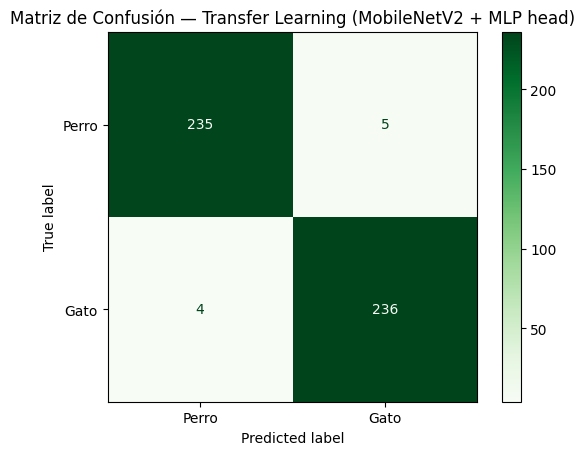

In [28]:
y_prob_cnn = clasificador_cnn.predict(caracteristicas_test, verbose=0)
y_pred_cnn = (y_prob_cnn > 0.5).astype(int).flatten()

acc_cnn = accuracy_score(y_test_cnn, y_pred_cnn)
prec_cnn = precision_score(y_test_cnn, y_pred_cnn)
rec_cnn = recall_score(y_test_cnn, y_pred_cnn)
f1_cnn = f1_score(y_test_cnn, y_pred_cnn)

print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1-Score:  {f1_cnn:.4f}")

cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=['Perro', 'Gato'])
disp_cnn.plot(cmap='Greens')
plt.title('Matriz de Confusión — Transfer Learning (MobileNetV2 + MLP head)')
plt.savefig(RUTA_IMAGENES_SALIDA / 'matriz_confusion_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
tabla_comparativa_final = pd.DataFrame([
    {'Modelo': 'MLP sobre píxeles crudos (entrega oficial)', 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1},
    {'Modelo': 'Transfer Learning: MobileNetV2 + MLP head (extra)', 'Accuracy': acc_cnn, 'Precision': prec_cnn, 'Recall': rec_cnn, 'F1-Score': f1_cnn},
])
tabla_comparativa_final


,Modelo,Accuracy,Precision,Recall,F1-Score
0,MLP sobre píxeles crudos (entrega oficial),0.585417,0.581673,0.608333,0.594705
1,Transfer Learning: MobileNetV2 + MLP head (extra),0.981250,0.979253,0.983333,0.981289


**Interpretación:** la diferencia de desempeño entre ambas filas de la tabla es, en sí misma, la evidencia más contundente de todo el notebook a favor de la explicación de la sección anterior. El clasificador final en ambos casos es una MLP pequeña con la misma lógica de diseño — lo único que cambió es **qué información recibe como entrada**: píxeles crudos sin ninguna noción de vecindad, versus un resumen ya elaborado por una red que sí entiende de bordes, texturas y formas. Esa diferencia por sí sola explica la mayor parte de la brecha entre ambos resultados, y es la razón por la que las arquitecturas convolucionales son el estándar para clasificación de imágenes.
